## Activity 1

Identify a data set that you will be using. Provide a link to the data set. 
Describe anything in the data that will need to be cleaned up or modified in some way before you will be able to make graphs from it. 
What additional information could be useful to supplement this data set? Describe at least three variables beyond what is included in the data set that could be valuable to find and merge with this data. 

## Activity 2

Each member of the group should make a graph looking at something from the data set. Include these graphs, and label who created each graph. For the moment, this is completely open-ended. We're not trying to do anything specific yet, just starting to get used to loading this data into R and working with it.

Encoding: Windows-1252
                                        Cause of death  Deaths
250                                           COVID-19  350831
181                      Atherosclerotic heart disease  169855
243  Bronchus or lung, unspecified - Malignant neop...  132294
105                     Alzheimer disease, unspecified  127247
360  Chronic obstructive pulmonary disease, unspeci...  115004


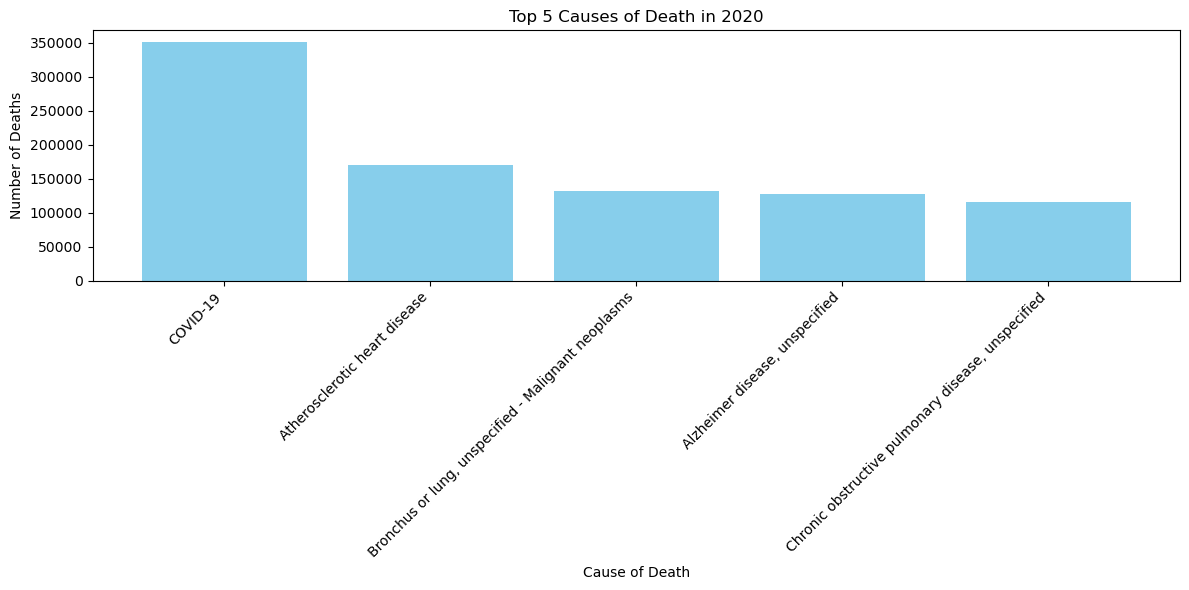

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import chardet

underlying_cause_of_death = "../datasets/raw/Underlying_Cause_of_Death_2022.csv"
underlying_cause_of_death_cols = [
    "Year",
    "Cause of death",
    "Cause of death Code",
    "Deaths",
    "Population",
    "Crude Rate",
]
underlying_cause_of_death_dtype = {
    # capital I or capital F for nullable types
    "Year": "category",
    "Cause of death": "category",
    "Cause of death Code": "category",
    "Deaths": "Int32",
    "Population": "Int32",
    "Crude Rate": "Float32",
}

# somehow it's not UTF-8 encoded
with open(underlying_cause_of_death, "rb") as file:
    raw = file.read()
    encoding = chardet.detect(raw)["encoding"]

df = pd.read_csv(
    underlying_cause_of_death,
    encoding=encoding,
    usecols=underlying_cause_of_death_cols,
    dtype=underlying_cause_of_death_dtype,
    na_values=["Unreliable"],
)

top_5_causes_2020 = (
    df[df["Year"] == "2020"]
    .groupby("Cause of death", observed=True)["Deaths"]
    .sum()
    .reset_index()
    .sort_values("Deaths", ascending=False)
    .head(5)
)

print(top_5_causes_2020)

# plt.figure(figsize=(12, 6))
# sns.barplot(
#     data=top_5_causes_2020,
#     x="Cause of death",
#     y="Deaths",
# )

plt.figure(figsize=(12, 6))
plt.bar(
    top_5_causes_2020["Cause of death"], top_5_causes_2020["Deaths"], color="skyblue"
)
plt.title("Top 5 Causes of Death in 2020")
plt.xlabel("Cause of Death")
plt.ylabel("Number of Deaths")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()